In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


Column Name | Type	| Unit | Values	Description

age |	integer | years 	| Age of the patient

anaemia |	binary | 0 = No, 1 = Yes | Decrease of red blood cells or hemoglobin

creatinine_phosphokinase |	integer |	mcg/L |	Level of CPK enzyme in the blood

diabetes |	binary | 0 = No, 1 = Yes |	Whether the patient has diabetes

ejection_fraction |	integer | percentage |	Percentage of blood leaving the heart at each contraction

high_blood_pressure |	binary | 0 = No, 1 = Yes |	Whether the patient has hypertension

platelets |	float |	kiloplatelets/mL |	Platelet count in the blood

serum_creatinine |	float |	mg/dL |	Level of serum creatinine in the blood

serum_sodium |	integer |	mEq/L | Level of serum sodium in the blood

sex	| binary  0 = Female, 1 = Male | Gender of the patient

smoking | binary |	0 = No, 1 = Yes |	Smoking habit

time |	integer |	days |	Follow-up period

DEATH_EVENT | binary | 0 = No, 1 = Yes |Target variable — whether the patient died during the follow-up period

In [5]:
df.DEATH_EVENT.value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

The label class has an imbalance distribution in favour of no death class. A stratified train-test spliting would be done

In [7]:
df.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [8]:
df.duplicated().sum()

0

# Preprocessing

- Change anaemia, diabetes, high_blood_pressure, sex and smoke to string label and then perform one-hot encoding on them to give equal weight to their categories
- use to_categorical() function to perform one_hot encoding for death event to be able to use **categorica_croossentropy** loss. However, we can leave the label as it is if we want to use **sparse_categorical_crossentropy**

In [10]:
label = {0: "No", 1: "Yes"}
label2 = {0: "Female", 1: "Male"}
df["anaemia"] = df["anaemia"].map(label)
df["diabetes"] = df["diabetes"].map(label)
df["high_blood_pressure"] = df["high_blood_pressure"].map(label)
df["smoking"] = df["smoking"].map(label)
df["sex"] = df["sex"].map(label2)
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,No,582,No,20,Yes,265000.00,1.9,130,Male,No,4,1
1,55.0,No,7861,No,38,No,263358.03,1.1,136,Male,No,6,1
2,65.0,No,146,No,20,No,162000.00,1.3,129,Male,Yes,7,1
3,50.0,Yes,111,No,20,No,210000.00,1.9,137,Male,No,7,1
4,65.0,Yes,160,Yes,20,No,327000.00,2.7,116,Female,No,8,1


In [11]:
# perform one-hot encoding on the caregorical data
df = pd.get_dummies(df, columns = ["anaemia", "diabetes", "high_blood_pressure", "smoking", "sex"], drop_first=False)
df.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,anaemia_No,anaemia_Yes,diabetes_No,diabetes_Yes,high_blood_pressure_No,high_blood_pressure_Yes,smoking_No,smoking_Yes,sex_Female,sex_Male
0,75.0,582,20,265000.00,1.9,130,4,1,True,False,True,False,False,True,True,False,False,True
1,55.0,7861,38,263358.03,1.1,136,6,1,True,False,True,False,True,False,True,False,False,True
2,65.0,146,20,162000.00,1.3,129,7,1,True,False,True,False,True,False,False,True,False,True
3,50.0,111,20,210000.00,1.9,137,7,1,False,True,True,False,True,False,True,False,False,True
4,65.0,160,20,327000.00,2.7,116,8,1,False,True,False,True,True,False,True,False,True,False


# Split the Data into X and y

In [13]:
X = df.drop(columns = "DEATH_EVENT")
X.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia_No,anaemia_Yes,diabetes_No,diabetes_Yes,high_blood_pressure_No,high_blood_pressure_Yes,smoking_No,smoking_Yes,sex_Female,sex_Male
0,75.0,582,20,265000.00,1.9,130,4,True,False,True,False,False,True,True,False,False,True
1,55.0,7861,38,263358.03,1.1,136,6,True,False,True,False,True,False,True,False,False,True
2,65.0,146,20,162000.00,1.3,129,7,True,False,True,False,True,False,False,True,False,True
3,50.0,111,20,210000.00,1.9,137,7,False,True,True,False,True,False,True,False,False,True
4,65.0,160,20,327000.00,2.7,116,8,False,True,False,True,True,False,True,False,True,False


In [14]:
y = df["DEATH_EVENT"]
y.head()

0    1
1    1
2    1
3    1
4    1
Name: DEATH_EVENT, dtype: int64

In [15]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
y_cc = to_categorical(y).astype("int64")

# Split the Data into Test and Train

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_cc, test_size = 0.3, stratify = y_cc, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((209, 17), (90, 17), (209, 2), (90, 2))

# Standardise X

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Build the FeedForward Deep Learning Model

In [21]:
# import the model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Dense
from tensorflow.keras.optimizers import Adam

In [22]:
ffn_model = Sequential()
# Add the import layer
ffn_model.add(InputLayer(shape=(X_train.shape[1],)))
# add the first hidden layer
ffn_model.add(Dense(20, activation="relu"))
# Add a second hidden layer
ffn_model.add(Dense(10, activation="relu"))
# Add a third hidden layer
ffn_model.add(Dense(5, activation="relu"))
# Add the output layer
ffn_model.add(Dense(2, activation="softmax"))
ffn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 637 (2.49 KB)

 Trainable params: 637 (2.49 KB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

In [24]:
opt = Adam(learning_rate=0.01)
ffn_model.compile(loss = "categorical_crossentropy", metrics=["accuracy"], optimizer=opt)
# Fit the model to the training dataset
history_1 = ffn_model.fit(X_train,y_train, epochs=20, batch_size=4, validation_split=0.2, verbose=1)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6866 - loss: 0.6120 - val_accuracy: 0.8571 - val_loss: 0.4259
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8228 - loss: 0.4252 - val_accuracy: 0.8571 - val_loss: 0.3733
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7947 - loss: 0.3981 - val_accuracy: 0.8333 - val_loss: 0.3288
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8746 - loss: 0.3157 - val_accuracy: 0.8571 - val_loss: 0.3604
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8407 - loss: 0.2964 - val_accuracy: 0.8333 - val_loss: 0.3960
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8848 - loss: 0.2996 - val_accuracy: 0.8810 - val_loss: 0.4974
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9027 - loss: 0.2551 - val_accuracy: 0.8333 - val_loss: 0.4155
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8888 - loss: 0.2666 - val_accuracy: 0.8333 - val_l

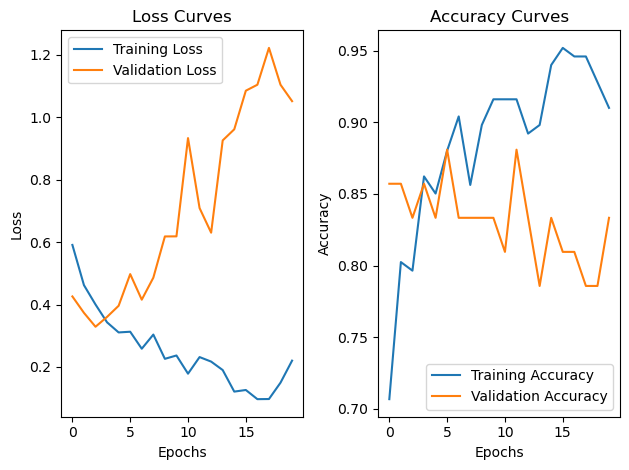

In [25]:
def plot_curves(history):
    # Plot training loss and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training accuracy and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()
    return
plot_curves(history_1)

As shown in the plots above the model performed better on the validation dataset than it did on the training dataset

# Evaluate the Model 

In [28]:
loss, acc = ffn_model.evaluate(X_test,y_test, verbose=0)
print("categorical_crossentropy loss is: ", loss)
print("accuracy is: ", acc)

categorical_crossentropy loss is:  0.6793467402458191
accuracy is:  0.7666666507720947


# Hyperparameter Tuning 

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.callbacks import EarlyStopping
# Define parameters
#parameters = {"batch_size": sp_randint(2,10),
#              "epochs": sp_randint(10,40)}
parameters = {
    "batch_size": [16, 32, 64],
    "epochs": [10, 20, 30] }

stop = EarlyStopping(monitor="val_loss", mode="min", verbose=1, patience=5)
# Wrap the model 
ffn_model = KerasClassifier(model=ffn_model, verbose=0)
# Instantiate the RandomizedSearch() 
ffn_grid = RandomizedSearchCV(ffn_model, parameters,n_iter=5, random_state=100, cv=5, scoring="accuracy")
history_2 = ffn_grid.fit(X_train, y_train, verbose=1, validation_split=0.2, callbacks=[stop])
best_estimator = ffn_grid.best_estimator_
best_model = best_estimator.model_ # the model was defined earlier at the KerasClassifier wrapper
# Now evaluate the model
loss, acc = best_model.evaluate(X_test, y_test, verbose=0) # The numerical y_test is used instead of one-hot encoded y_test
print("loss is: ", loss)
print("accuracy is: ", acc)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9197 - loss: 0.2261 - val_accuracy: 0.8235 - val_loss: 0.8796
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9518 - loss: 0.1779 - val_accuracy: 0.7647 - val_loss: 0.8215
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9825 - loss: 0.0809 - val_accuracy: 0.7941 - val_loss: 0.8324
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9709 - loss: 0.0844 - val_accuracy: 0.8235 - val_loss: 0.8423
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9778 - loss: 0.0690 - val_accuracy: 0.8235 - val_loss: 0.8656
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9707 - loss: 0.0551 - val_accuracy: 0.8235 - val_loss: 0.8819
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9743 - loss: 0.0698 - val_accuracy: 0.8235 - val_loss: 0.8981
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9513 - loss: 0.0674 - val_accuracy: 0.8235 - val_loss: 0.9208

# Generate Classification report and Confusion Matrix

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score 
# Get y_pred
y_pred = best_model.predict(X_test)
y_pred = np.argmax(y_pred, axis = 1) # changes y_pred from one-hot encoding
y_test_label = np.argmax(y_test, axis = 1) # changes y_pred from one-hot encoding
reports = classification_report(y_test_label, y_pred)
cm = confusion_matrix(y_test_label, y_pred)
print(reports)
cm = confusion_matrix(y_test_label, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step 
              precision    recall  f1-score   support

           0       0.88      0.74      0.80        61
           1       0.59      0.79      0.68        29

    accuracy                           0.76        90
   macro avg       0.74      0.77      0.74        90
weighted avg       0.79      0.76      0.76        90



array([[45, 16],
       [ 6, 23]], dtype=int64)

In [33]:
from sklearn.metrics import roc_auc_score 

roc_auc = roc_auc_score(y_test_label, y_pred)
roc_auc

0.7654041831543243

The model correctly predicted 20 death events but incorrectly predicted 41 death events as no death. Conversely, the model correctly predicted 26 no death event with only 3 no death events incorrectly predicted as death event. Overall, the model has an roc_auc score of 61.2%